## TASKS ##
 - Gulf Coast: Completed
 - East Coast: Not Completed

 - Need to figure out how to fix 1971 - 1983 lack of landfalls in Hurdat2
 - Find paper by Bove, O'Brian from AMS about landfalling systems
    - Found: 
         - Effect of El Nino on U.S Landfalling Hurricanes: https://journals.ametsoc.org/view/journals/bams/79/11/1520-0477_1998_079_2477_eoenoo_2_0_co_2.xml?rskey=2ZCRyf&result=2
               - Looks at the effect of Nino 3.4 on frequency of landfalling hurricanes (Can be used as a reference to infer overall trends for my own research)
         - Are Gulf Landfalling Hurricanes Getting Stronger?: https://journals.ametsoc.org/view/journals/bams/79/7/1520-0477_1998_079_1327_aglhgs_2_0_co_2.xml?rskey=2ZCRyf&result=1
               - Looks at the overall trends in intensity aswell as quantity of landfalling hurricanes
    

In [6]:
## Importing packages that will be used ##
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import scipy.stats as stats
import geopandas as gpd
from shapely.geometry import Point, LineString
from shapely.ops import unary_union, nearest_points
import fiona as fiona 

In [10]:
### Parsing the Hurdat2 Dataset ###
storms = []
with open('Data/hurdat2_8_28_25.csv') as hurdat2:
    info = hurdat2.readlines()
i = 0
while i < len(info):
    line = info[i].strip().split(',')
    storm_id = line[0].strip()
    storm_name = line[1].strip()
    track_entries = int(line[2].strip())
    year = storm_id[-4:]
    year = int(year) #Making year an int value

    tracks = [info[j].strip().split(',') for j in range(i+1, i+1+track_entries)]
    df = pd.DataFrame(tracks, columns = ["date", "time", "ID", "Cylcone Type", "Lat", "lon",
                                              "Max Winds", "Min Pressure", "34kt NEQ", "34kt SEQ", 
                                              "34kt SWQ", "34kt NWQ", "50kt NEQ", "50kt SEQ", "50kt SWQ",
                                              "50kt NWQ", "64kt NEQ", "64kt SEQ","64kt SWQ", "64kt NWQ", 
                                              "Radius of Max Winds"])
    df["storm_id"] = storm_id
    df["storm_name"] = storm_name
    df["year"] = year

    if (1971 <= year <= 1983) or any(idv.strip() == 'L' for idv in df['ID'].values):
        storms.append(df)
    i += track_entries + 1
       

### fixing 1971 to 1983 lack of landfall data using geopandas and shapely ###

#Loading all tracks
tracks = pd.concat(storms, ignore_index = True)

#Converting lat lon to numeric values
def parse_coord(s):
    s = str(s).strip()
    if s == '' or s.lower() in ('nan','-999'):
        return np.nan
    last = s[-1].upper()
    if last in ('N','S','E','W'):
        try:
            val = float(s[:-1])
        except:
            return np.nan
        if last in ('S','W'):
            return -val
        return val
    try:
        return float(s)
    except:
        return np.nan
tracks['lat_num'] = tracks['Lat'].apply(parse_coord)
tracks['lon_num'] = tracks['lon'].apply(parse_coord)
# Datetime for ordering
tracks['date_parsed'] = pd.to_datetime(tracks['date'].astype(str), format='%Y%m%d', errors='coerce')
tracks['time_str'] = tracks['time'].astype(str).str.zfill(4)
tracks['datetime'] = pd.to_datetime(tracks['date_parsed'].dt.strftime('%Y-%m-%d') + ' ' +
                                    tracks['time_str'].str.slice(0,2) + ':' +
                                    tracks['time_str'].str.slice(2,4),
                                    errors='coerce')

# Filtering for only 1971 to 1983 #
tracks['year'] = tracks['year'].astype(int)
gap_mask = tracks['year'].between(1971,1983)
non_gap_mask = ~gap_mask

#################################################### ONLY USING L FLAGS FOR NON_GAP YEAR STORMS ######################################################
# Using "L" flags to identify landfalls outside the gap period
L_flags = tracks[non_gap_mask & (tracks['ID'].astype(str).str.strip() == 'L')].copy()

# One landfall per storm for Non-gap Storms #
L_flags = L_flags.sort_values(['storm_id','datetime']).reset_index(drop=True)


##################################################### USING GEOPANDAS TO FIND LANDFALLS FOR GAP YEAR STORMS ######################################################
# Locating Gap years #
gap_tracks = tracks[gap_mask].copy()
#dropping rows with NaN values in lat_num or lon_num
gap_tracks_lat_lons = gap_tracks.dropna(subset=['lat_num', 'lon_num']).copy()

# Creating GeoDataFrame from gap_tracks DataFrame #
gdf_gap_tracks = gpd.GeoDataFrame(
    gap_tracks_lat_lons, 
    geometry = gpd.points_from_xy(gap_tracks_lat_lons['lon_num'], gap_tracks_lat_lons['lat_num']),
    crs = "EPSG:4326"
)

# Loading US Coastline Shapefile #
shapefile = shpreader.natural_earth(resolution='10m', category='physical', name ='land')
reader = shpreader.Reader(shapefile)
land_geom = list(reader.geometries())
world = gpd.GeoDataFrame(geometry = land_geom, crs="EPSG:4326")
land = world.unary_union

## Land test  ##
gdf_gap_tracks['on_land'] = gdf_gap_tracks.geometry.within(land)

# Sorting by each storm and time of landfall #
gap_tracks_sorted = gdf_gap_tracks.sort_values(['storm_id', 'datetime'])

# Finding landfall for each storm in gap years (ocean to land transition for each storm) #
landfalls = []
for sid , grp in gap_tracks_sorted.groupby('storm_id'):
    grp = grp.sort_values('datetime').reset_index(drop=True)
    if grp.shape[0] == 0:
        continue
    previous_on_land  = grp['on_land'].shift(fill_value=False)
    landfall = grp['on_land'] & (~previous_on_land)
    if landfall.any():
        #landfalls.extend(grp[landfall].to_dict('records'))

    
        # Snapping landfall points to the coastline #
        for _, row in grp[landfall].iterrows():
            landfall_point = row.geometry
            landfall_snapped = nearest_points(land.boundary , landfall_point)[0]
            new_row = row.copy()
            new_row['lon_num'] = landfall_snapped.x
            new_row['lat_num'] = landfall_snapped.y
            new_row['geomtry'] = landfall_snapped
            landfalls.append(new_row)


# Creating DataFrame of Gap Year Landfalls #
if landfalls:
    gap_landfalls = pd.DataFrame(landfalls)


# Combining Landfalls from Gap and Non-Gap Years #
Landfall_only = pd.concat([L_flags, gap_landfalls], ignore_index = True)


/Users/epalmer/Meteorology-Research-Dr.-Misra-/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>

In [32]:
### Altering the Dataframe ###
#Landfalling_storms['date'] = pd.to_datetime(Landfalling_storms['date'], dayfirst = "True",)
#Landfall_only = Landfalling_storms[Landfalling_storms["ID"].str.strip() == "L"] # Showing only the landfalls for each storm
Landfall_only = Landfall_only.set_index(['storm_name', 'date', 'storm_id']) ## Setting a multi-index with storm name and year
Landfall_only = Landfall_only.drop(columns = ['ID']) # Dropping ID and Storm_id cause they are no longer needed

### Converting Maximum winds in pandas dataset into Category of Storm ###
Landfall_only["Max Winds"] = pd.to_numeric(Landfall_only["Max Winds"].values)
#Landfall_only["Max Winds"] = Landfall_only["Max Winds"] * 1.15078 # ----> We do no need to convert to mph, however if needed uncomment this line and change the conditions below for MPH rather than knots
Landfall_only["category"] = np.select([
    Landfall_only["Max Winds"] <= 33, #38 mph 
    Landfall_only["Max Winds"] < 64, #73 mph
    Landfall_only["Max Winds"] < 82, #95 mph
    Landfall_only["Max Winds"] < 95, #110 mph
    Landfall_only["Max Winds"] < 113, #129 mph
    Landfall_only["Max Winds"] < 137, #156 mph
    Landfall_only["Max Winds"] >= 137, #157+ mph
], 
[
    "TD",
    "TS",
    "Cat 1",
    "Cat 2",
    "Cat 3",
    "Cat 4",
    "Cat 5"
],
default = 'Unknown')

In [33]:
### Saving to Excel ###
# Change dataset to group by year and storm_name 
Landfall_only_sorted = Landfall_only.sort_values(['year','storm_name'])
Landfall_only_sorted.to_excel("Landfalling_Storms_1851_2024_test.xlsx", engine = 'openpyxl')

Text(0.5, 1.0, 'Landfalling Atlantic Tropical Cyclones (1851-2024)')

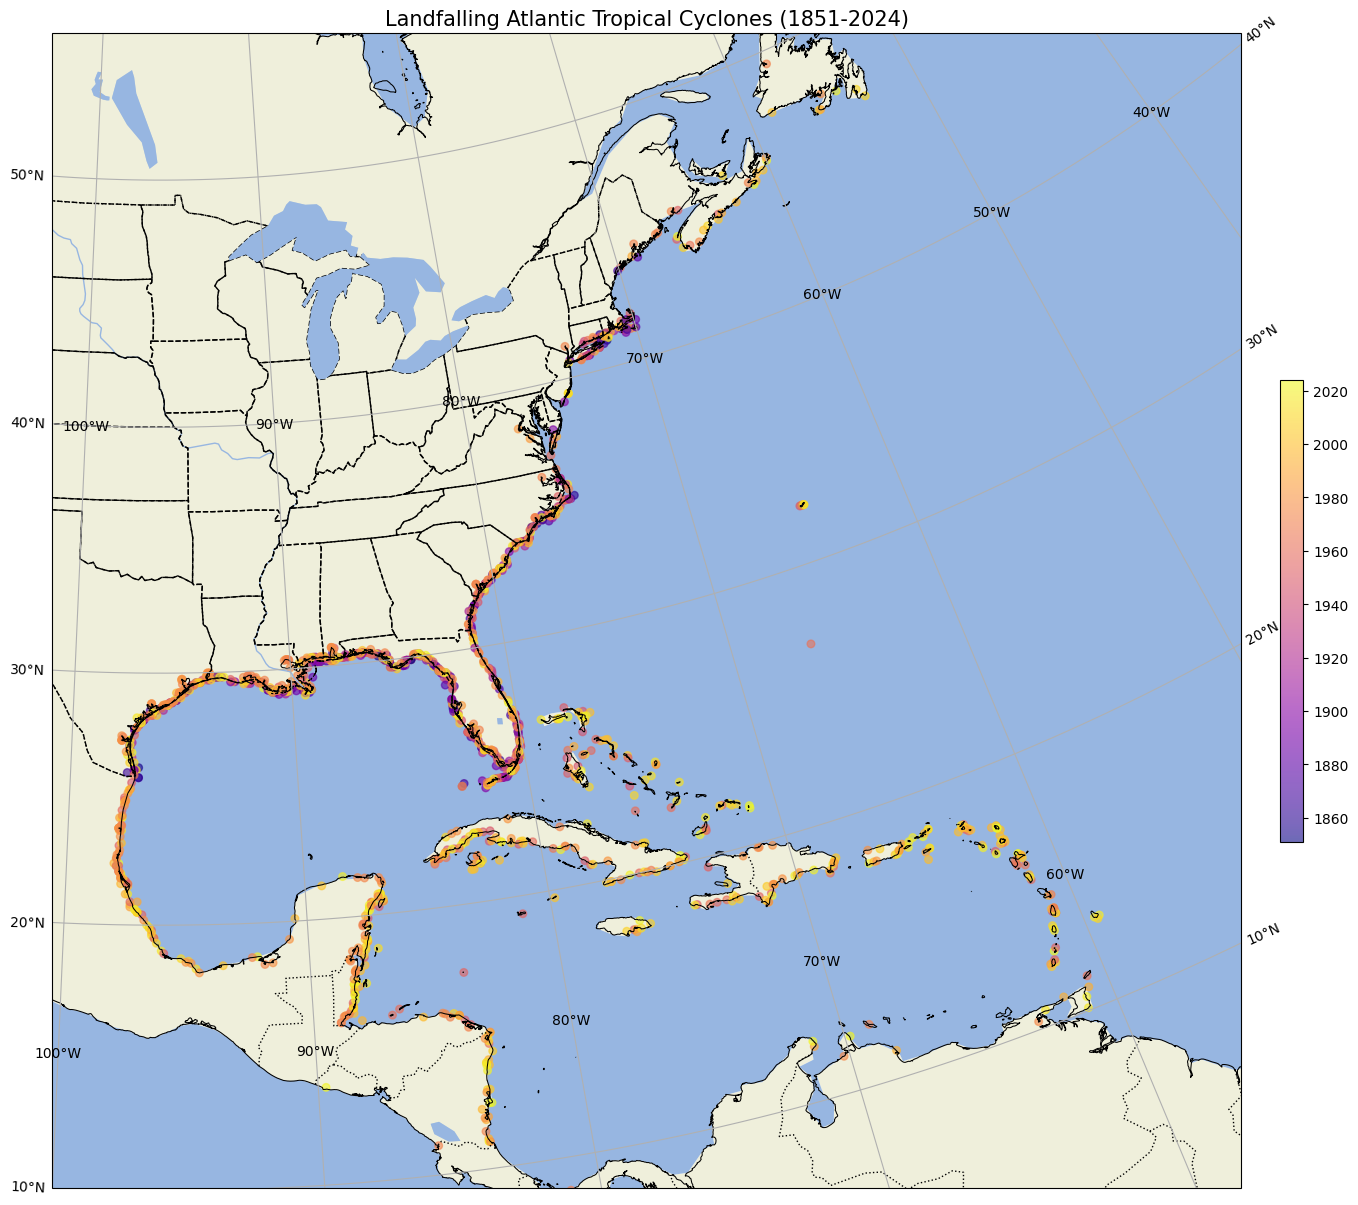

In [34]:
### Plotting the Landfalling Storms ###
fig, ax = plt.subplots(figsize= (25,15), subplot_kw = {'projection':ccrs.LambertConformal()})
## Defining Lat and Lon ##
lf = Landfall_only.copy()
Lat = lf['lat_num']
Lon = lf['lon_num']
mask = Lat.notna() & Lon.notna()
Lat = Lat[mask]
Lon = Lon[mask]
years = pd.to_numeric(lf.loc[mask, 'year'], errors='coerce')
##Converting Years to numeric values for color mapping ##
#Landfall_only['year'] = pd.to_numeric(Landfall_only['year'].values)
#Landfall_only['category'] = pd.to_numeric(Landfall_only['category'].values, errors = 'coerce')
## Making the Map##
ax.set_extent([-100, -55, 10, 50], crs=ccrs.PlateCarree())
map_data = ax.scatter(Lon, Lat,  c = years, 
                      cmap = 'plasma', s= 30, alpha = 0.6, 
                      transform=ccrs.PlateCarree())
cbar = plt.colorbar(map_data, ax=ax, shrink = 0.4, orientation = 'vertical', pad = 0.02)
## Adding features ##
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.coastlines(resolution = '10m', linewidth = 0.75) # Added very high res coastlines to see small islands
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)
ax.gridlines(draw_labels = True)
ax.add_feature(cfeature.STATES, linestyle = '--')
ax.add_feature(cfeature.LAKES)
## Adding Title ##
plt.title('Landfalling Atlantic Tropical Cyclones (1851-2024)', fontsize = 15)


In [35]:
## Assigning States to each Landfall ##
Landfall_only = Landfall_only.reset_index() #Resetting index to make storm_name and year columns again

def assign_coast(lon,lat):
    '''Function assigns a coastline to each landfalling storm based on the lat and lon location found in the hurdat2 Dataset'''
    coasts =[]
##################### GULF COAST BOXES ######################

    # Texas to louisiana Bounding Box#
    Texas_louisiana = (-98 <= lon <= -88.80) and (25.8 <= lat <= 30.90)
    Alabama_mississippi = (-88.80 < lon <= -87.75) and (29.5 <= lat <= 31.00)
    #us_box_wout_FL = (-99 <= lon <= -86) and (26 <= lat <= 31)
    Fl_pan = (-87.52 <= lon <= -84.75) and (29.5 <= lat <= 31.10)
    Fl_pens = (-84.75 < lon <= -81.6) and (24.4 <= lat <= 29.5)
    # Combining boxes for simplicity in if statements #
    Alabama_mississippi_Fl_coast = Alabama_mississippi or Fl_pan or Fl_pens
    #us_box = us_box_wout_FL or Fl_pan or Fl_pens
    #gulf_coast = Texas_louisiana or Alabama_mississippi_Fl_coast ## Not needed but keeping just in case we want to look at whole gulf coast again

##################### EAST COAST BOXES ######################
    #Florida east coast box
    Fl_east_coast = (-81.6 <= lon <= -79.8) and (24.4 <= lat <= 31.10)
    #GA to NC Coast box 
    GA_NC_coast = (-81. <= lon <= -75.4) and (31 <= lat <= 36.5)
    #VA to ME coast box 
    VA_ME_coast = (-76.5 <= lon <= -66.90) and (36.5 <= lat <= 47.5)
    # Combining boxes for simplicity in if statements # 
    Fl_to_NC = Fl_east_coast or GA_NC_coast
    ATL_east_coast = Fl_to_NC or VA_ME_coast
    if Texas_louisiana:
        coasts.append('Texas_louisiana_coast')
    if Alabama_mississippi_Fl_coast:
        coasts.append('Alabama_mississippi_Fl_coast')
    if Fl_to_NC:
        coasts.append('Fl_to_NC_coast')
    if VA_ME_coast: 
        coasts.append('VA_ME_coast')
    return ',' .join(coasts) if coasts else None
Landfall_only['Coast Line'] = Landfall_only.apply(lambda row: assign_coast(row['lon_num'], row['lat_num']), axis=1)

Texas_louisiana_coast: slope=0.004560494319314332, r_value=0.19675696264123557, p_value=0.009263240029457385
Alabama_mississippi_Fl_coast: slope=0.0006925026339018767, r_value=0.03722692102117052, p_value=0.625771919155864
Fl_to_NC_coast: slope=0.004973945727384037, r_value=0.2291993673462444, p_value=0.0023488836726927873
VA_ME_coast: slope=0.0005273498675930411, r_value=0.05027252324361323, p_value=0.5100389161582648


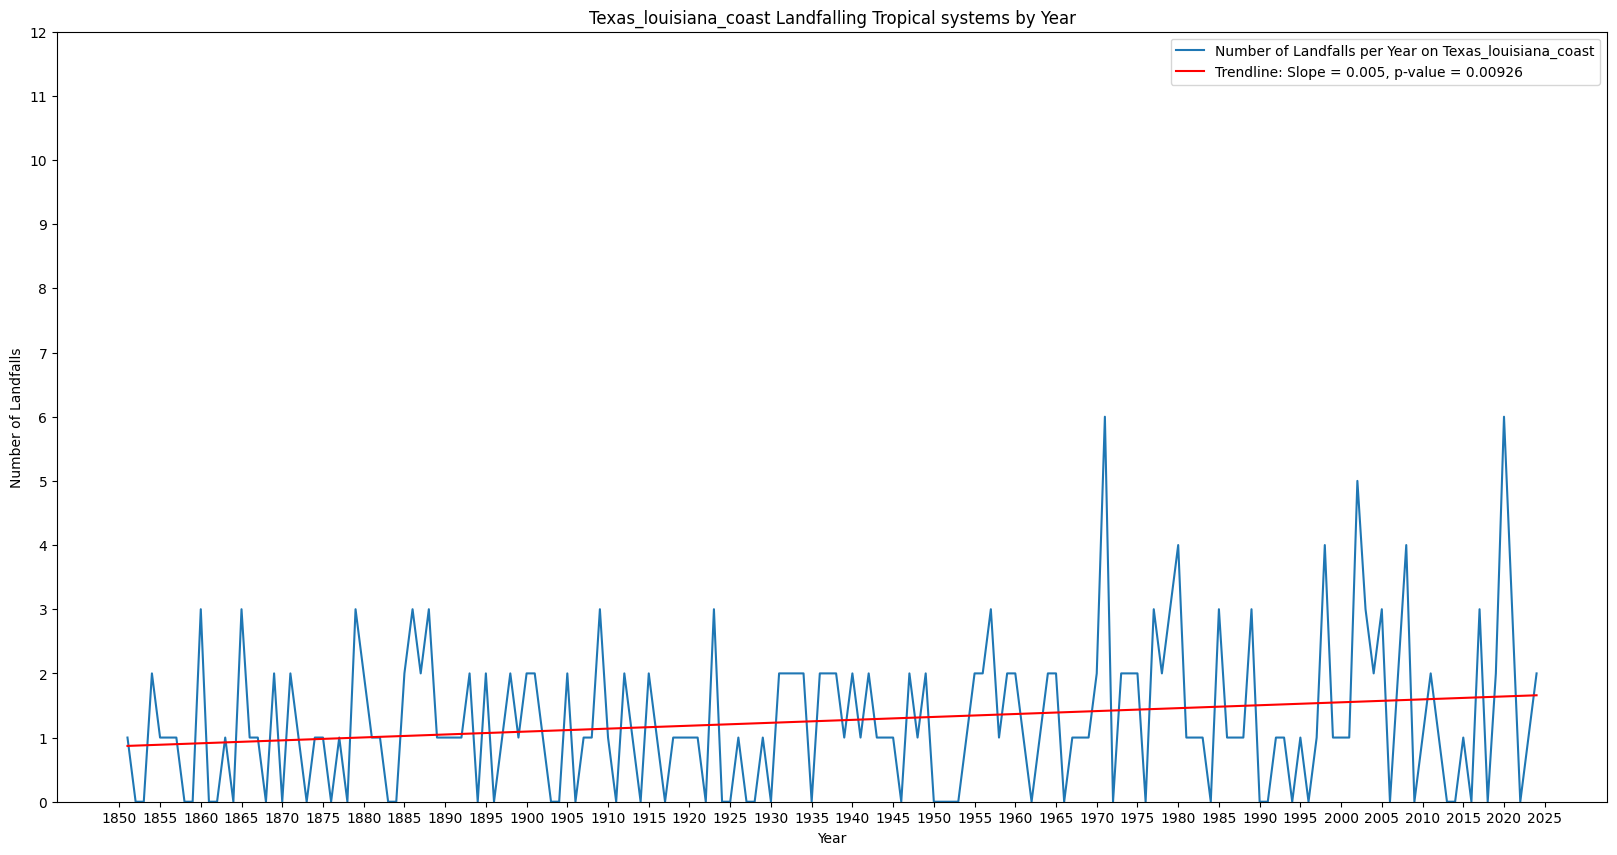

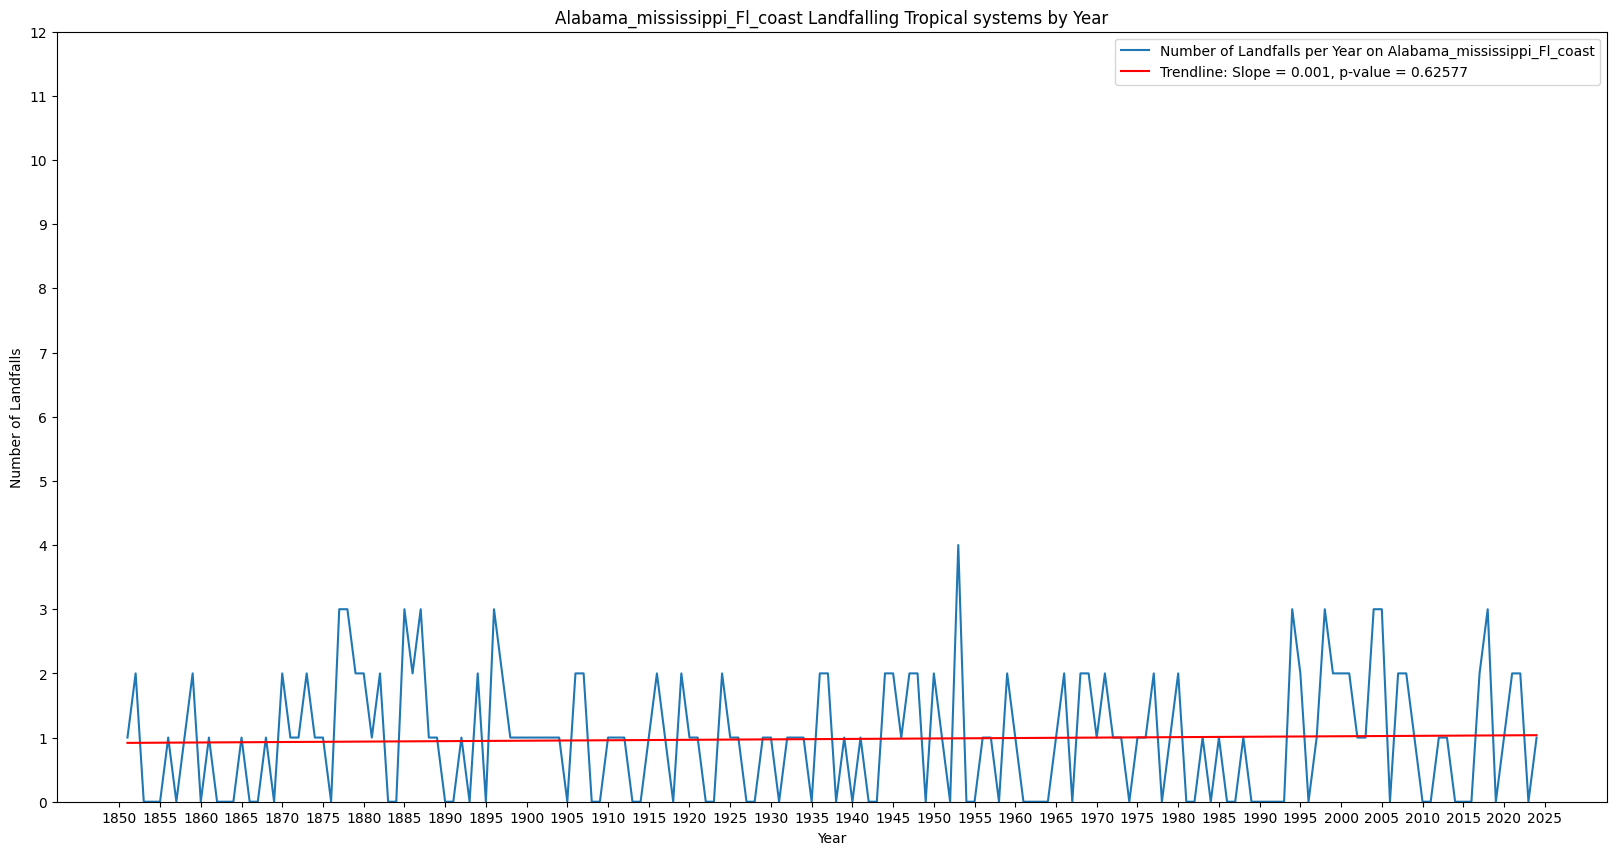

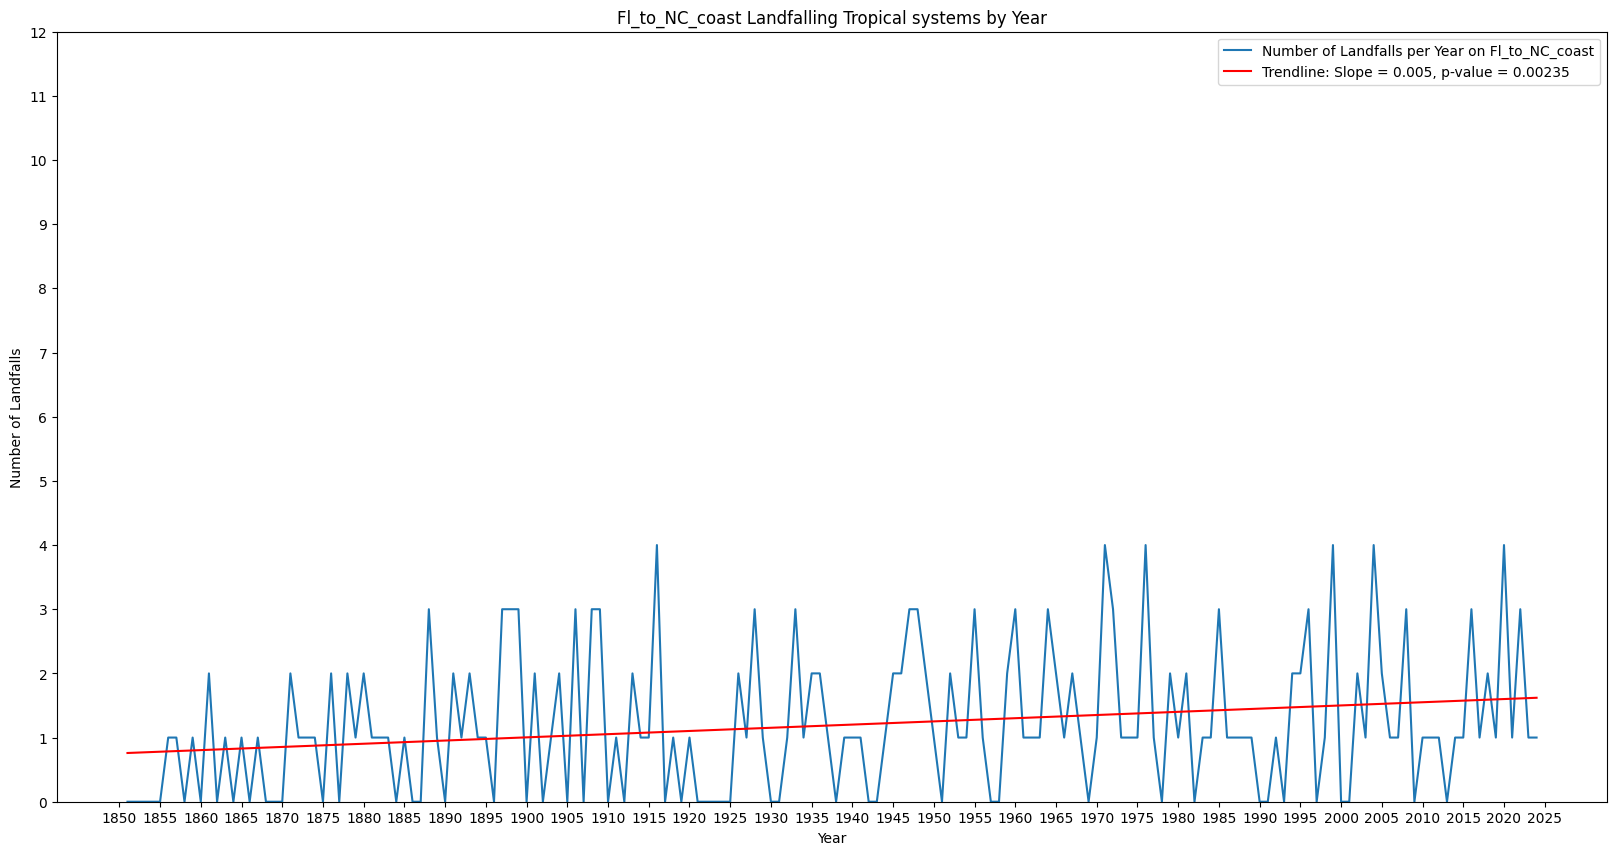

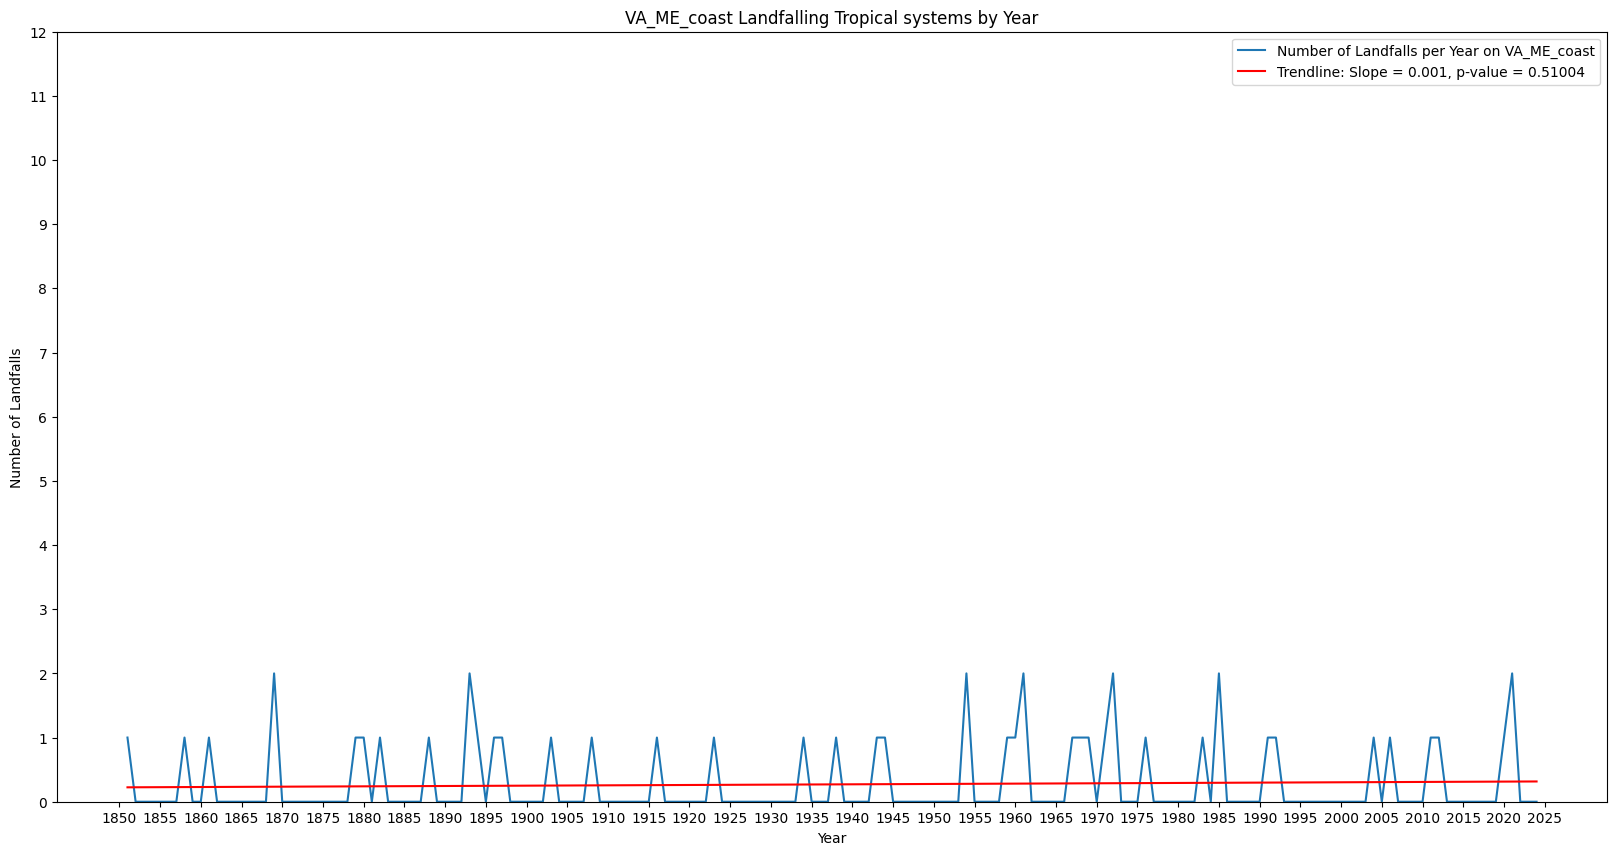

In [ ]:
### Plotting Landfall Frequency by Year for each Coastline ###
coasts = ['Texas_louisiana_coast', 
          'Alabama_mississippi_Fl_coast',
          'Fl_to_NC_coast',
          'VA_ME_coast'] # add other coastlines as needed
def plot_landfall_frequency(coasts, save_freq = False):

    '''Function that takes the coastlines from the assign coastlines functions and then uses that to plot the frequency of landfalling tropical system by year for each coastline given in the coasts list'''

    for coast in coasts:
        coast_data = Landfall_only[Landfall_only['Coast Line'].str.contains(coast, na=False)]
        coast_data_altered = coast_data.drop_duplicates(subset=['storm_name','storm_id','year','Coast Line'])
        all_years = np.arange(Landfall_only['year'].min(), Landfall_only['year'].max()+1)
        frequency = coast_data_altered.groupby('year').size().reindex(all_years, fill_value=0)
        ## Plotting the frequency ##
        fig, ax = plt.subplots(figsize=(20, 10))
        ax.plot(frequency.index, frequency, label=f'Number of Landfalls per Year on {coast}')
        ax.set_title(f'{coast} Landfalling Tropical systems by Year')
        ax.set_xlabel("Year")
        ax.set_ylabel("Number of Landfalls")
        x_range = np.arange(1850, 2026, 5)
        ax.set_xticks(x_range)
        ax.set_yticks([0,1,2,3,4,5,6,7,8,9,10,11,12])
        ax.set_ylim(bottom=0)
        # Creating a trend line #
        years = frequency.index.astype(int)
        counts = frequency.values
        z = np.polyfit (years, counts, 1)
        p = np.poly1d(z)
        # Adding a linear regression line for each plot using scipy #
        slope, intercept, r_value, p_value, std_err = stats.linregress(years, counts) 
        trend_labels = f"Trendline: Slope = {slope:.3f}, p-value = {p_value:.5f}"
        print(f'{coast}: slope={slope}, r_value={r_value}, p_value={p_value}')
        Trendline = ax.plot(years, intercept + slope * years, "r-", label=trend_labels)
        ## Adding a Legend ##
        ax.legend()
        # Allows the user to save the frequency as a .txt file #
        if save_freq:
            frequency.name = 'count'
            frequency.to_csv(f"{coast.replace(' ',' ')}_Landfall_frequency.txt" , header=True, sep=':', index_label='Year')
    return

plot_landfall_frequency(coasts, save_freq=False #Uncomment to save frequency as a txt file
)


In [41]:
#Wtf is happening #

year_check = Landfall_only[
    (Landfall_only['year'] == 2020) &
    (Landfall_only['Coast Line'] == 'Fl_to_NC_coast')
].copy()

# See which storms you’re actually counting
print(year_check[['storm_id', 'storm_name', 'datetime', 'lat_num', 'lon_num']]
      .sort_values(['storm_id', 'datetime'])
      .drop_duplicates(subset=['storm_id']))

      storm_id storm_name            datetime  lat_num  lon_num
190   AL022020     BERTHA 2020-05-27 01:33:00     32.9    -79.7
855   AL092020     ISAIAS 2020-08-04 00:31:00     33.9    -78.5
1129  AL192020      SALLY                 NaT     25.6    -80.2
1160  AL292020        ETA 2020-11-09 00:40:00     24.9    -80.7


# ANALYSIS OF THE ABOVE GRAPHS #

**Gulf Coast**
    1. There seems to be a big increase in the trend with the statistical linear-regression returning a significant P-Value
    2. The significant trend seems to be attributed to the lack of data before the satelite ERA of Mexico landfalling systems

**Mexico Gulf Coast**
    1. There is also a significant trend in the data however, it is clear that it is solely attributed to the fact that there is no data pre satelite ERA for landfalling tropical systems

**American Gulf Coast**
    1. There is a non-signficant trend in landfalling tropical systems with the trendline only showing a roughly 0.001 increase in landfalling systems year on year. 
    
**Overall conclusion as of 10-13-2025** - This is subject to change as analysis continues
    1. There is a non-signficant trend in the number of landfalling systems in the gulf of mexico due to the fact that there is no data pre-satelite ERA for the mexico coast. Ideally I would like to further this reasearch by looking at the trends from the Satelite ERA 
      (roughly beginning in the 1940s) and seeing if there is a trend. 
    1. An interesting thing to note is that there is a cyclical or an ocisilation in the frequency of landfalling tropical systems which bears resembalence to the oscillations seen with the AMV and Nino3.4 index. (Could those play a bigger role in landfalling tropical system frequency?)